In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape
import sklearn

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)

def sigmoid(x):
    return 1/(1+np.exp(-x))
def logit(x):
    return np.log(x/(1-x)) 

In [2]:
def add_grid_coastlines(ax):
    ax.coastlines(color='.4', lw=.5)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2,
        color='.7'
    )

# Make cyclone maps

In [3]:
cluster = LocalCluster(n_workers=8, memory_limit='12GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 64,Total memory: 96.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34857,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41093,Total threads: 8
Dashboard: http://127.0.0.1:41547/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:46017,


In [4]:
ds_features = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_100km_1940-2024_NPS_v2.zarr").load()

In [6]:
run_id ='h82d4u1m'

ds_predictions = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_model_skill.nc').sortby('time')
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v3_lrpzplus.nc').transpose('y','x',...)
# ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
# ds_attrs['moran_I'] = ds_moran.Moran_I

lrp_normed = ds_attrs.attributions_lrp.sum('var_name')/ds_attrs.attributions_lrp.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed
# # cycs = cycs.query("msl<100000")
gdf_cyclones = gpd.read_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data_watershed_thresh0.0005_buffer500_v2_zplus.geojson')
gdf_cyclones = gdf_cyclones.set_crs(proj, allow_override=True)
# gdf_cyclones['patch_pixel_count'] = (gdf_cyclones.patch_area/1.384083e+04).round(1)
all_cyclones = gpd.read_file('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/all_cyclones.geojson')
all_cyclones = all_cyclones.set_crs(proj, allow_override=True)



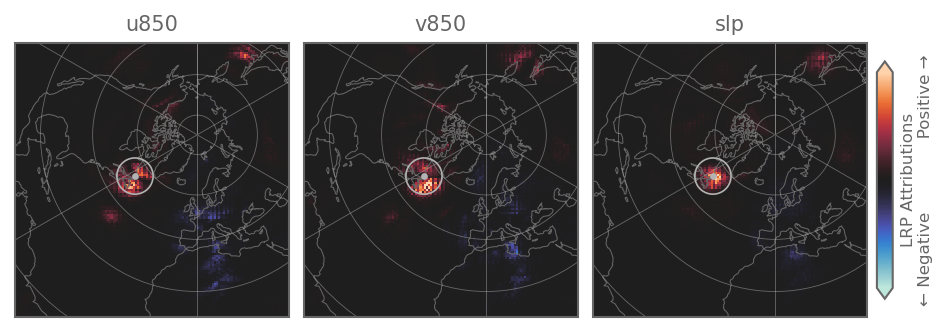

In [23]:
plot = ds_attrs.attributions_lrp.sel(time_of_event='2020-03-25', timestep_past=-4).plot( col='var_name',vmax=.002, subplot_kws=dict(projection=proj), transform=proj, cmap='icefire', 
                                                                                        cbar_kwargs=dict(extend='both', shrink=.7, pad=.01, aspect=15), size=2.5, aspect=.8, rasterized=True)
for ax in plot.axs.flatten():
    # all_cyclones.set_index('track_id').loc[855287].iloc[[1]].reset_index().plot(
    #             ax=ax, marker='o', color='none', edgecolor='C9', linewidth=.8,
    #             )
    add_grid_coastlines(ax)
    all_cyclones.set_index('track_id').loc[855287].iloc[[1]].reset_index().buffer(1_000_000).plot(
            ax=ax, marker='o', color='none', edgecolor='.7', linewidth=.8,
            zorder=100)
    all_cyclones.set_index('track_id').loc[855287].iloc[[1]].reset_index().plot(
            ax=ax, legend=False, marker='o', color='.7',
            markersize=5, zorder=100)
#     ds_features.sel(time='2020-03-21').msl.rolling(x=3,y=3,center=True).mean().plot.contour(levels=np.arange(96000, 108000,500), colors='.8', linewidths=.3, ax=ax, alpha=.6)
    # ax.coastlines()
axs= plot.axs.flatten()
plot.cbar.ax.set_yticks([])
plot.cbar.ax.set_ylabel('LRP Attributions\n← Negative              Positive →') 
axs[0].set_title('u850')
axs[1].set_title('v850')
axs[2].set_title('slp')
plt.savefig('plots/example_cyclone_variables_overlay.svg', dpi=300, transparent=True)

# ds_attrs.attributions_lrp.sel(time_of_event='2022-08-03', timestep_past=-3).plot(col='var_name')

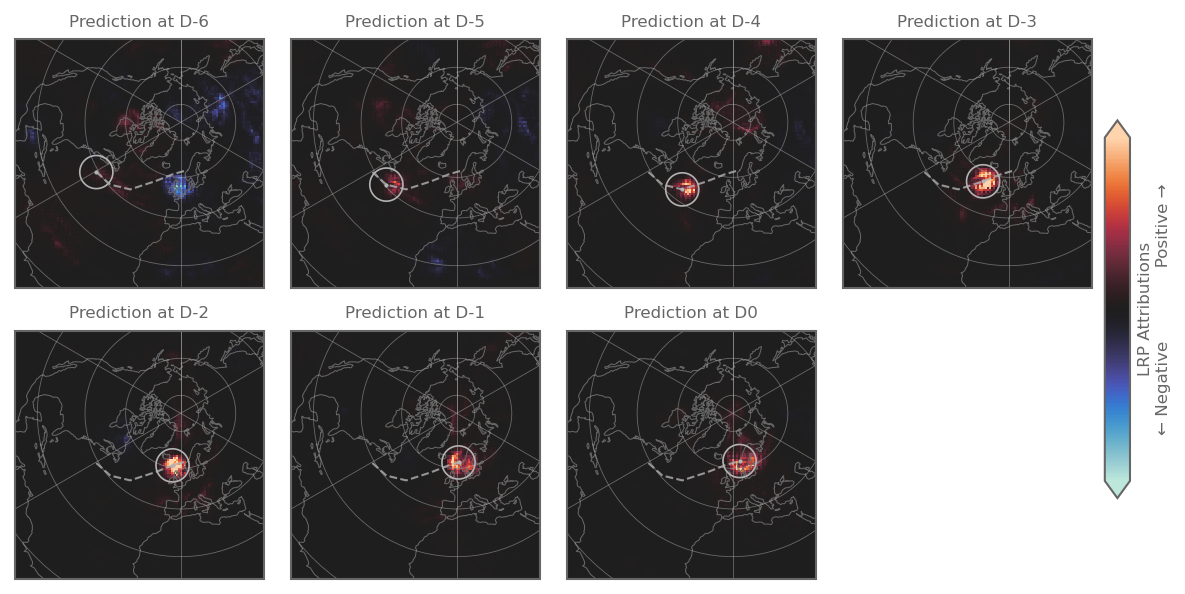

In [22]:
plot = ds_attrs.lrp_normed.sel(time_of_event='2016-08-09').plot(col='timestep_past', cmap='icefire', transform=proj,
                                                         subplot_kws=dict(projection=proj), vmax=.005,
                                                         aspect=1, size=2, rasterized=True, col_wrap=4,
                                                         cbar_kwargs=dict(extend='both', shrink=.7, pad=.01, aspect=15))
for k,ax in enumerate(plot.axs.flatten()[:-1]):
    add_grid_coastlines(ax)
    sns.lineplot(all_cyclones.set_index('track_id').loc[778065].reset_index(), 
            x='x',y='y', ax=ax, legend=False, alpha=.8, ls='--', color='.7')
    
    all_cyclones.set_index('track_id').loc[778065].iloc[[k]].reset_index().buffer(1_000_000).plot(
            ax=ax, marker='o', color='none', edgecolor='.7', linewidth=.8, zorder=100,
            )
    all_cyclones.set_index('track_id').loc[778065].iloc[[k]].reset_index().plot(
            ax=ax, legend=False, marker='o', color='.7',
            markersize=1, zorder=100)
    
    ax.set_extent([-1e7,5e6, -1e7, 5e6], crs=proj)
    ax.set_title(f'Prediction at D{-6+k}', size=8)
plot.cbar.ax.set_yticks([])
plot.cbar.ax.set_ylabel('LRP Attributions\n← Negative              Positive →') 

plt.savefig('plots/example_cyclone_track_overlay.svg', dpi=300, transparent=True)

# Plot 0: model skill

In [44]:
all_f1 = []
for thresh in tqdm(np.arange(0,1.01,0.01)):
    FP = ((ds_predictions.targets<1)&(ds_predictions.predictions>=thresh)).groupby(ds_predictions.dataset).sum()
    TP = ((ds_predictions.targets==1)&(ds_predictions.predictions>=thresh)).groupby(ds_predictions.dataset).sum()
    FN = ((ds_predictions.targets==1)&(ds_predictions.predictions<thresh)).groupby(ds_predictions.dataset).sum()
    TN = ((ds_predictions.targets<1)&(ds_predictions.predictions<thresh)).groupby(ds_predictions.dataset).sum()
    PR = (TP/(TP+FP)).fillna(0)
    RE = (TP/(TP+FN)).fillna(0)
    F1 = 2*PR*RE/(PR+RE)
    all_f1.append(F1.assign_coords(threshold=thresh))

F1 = xr.concat(all_f1, dim='threshold')

  0%|          | 0/101 [00:00<?, ?it/s]

Text(0, 0.5, 'Predicted probability of heavy rainfall')

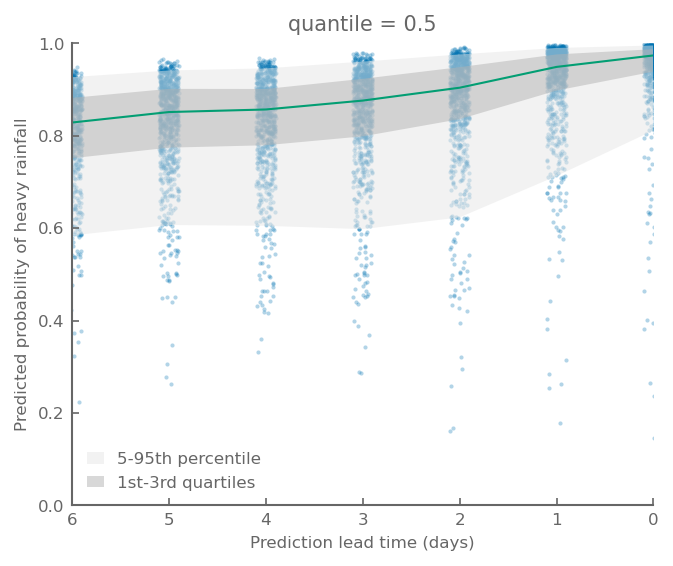

In [122]:
ds_ = ds_predictions.predictions.where(ds_predictions.targets==1).quantile([0.05,0.25,0.5,0.75,0.95], dim='time')
fig, ax= plt.subplots(figsize=(5,4))

ax.fill_between(ds_.timestep, ds_.sel(quantile=0.05), ds_.sel(quantile=0.95), color='.9', alpha=.5, label='5-95th percentile', edgecolor='none')
ax.fill_between(ds_.timestep, ds_.sel(quantile=0.25), ds_.sel(quantile=0.75), color='.7', alpha=.5, label='1st-3rd quartiles', edgecolor='none')
ds_.sel(quantile=0.5).plot(ax=ax, color='C2')
sns.stripplot(df_, x='timestep', y='predictions', alpha=.3, s=2, zorder=0)
ax.set_ylim(0,1)
ax.set_xlim(6,0)
ax.legend()
ax.set_xlabel('Prediction lead time (days)')
ax.set_ylabel('Predicted probability of heavy rainfall')

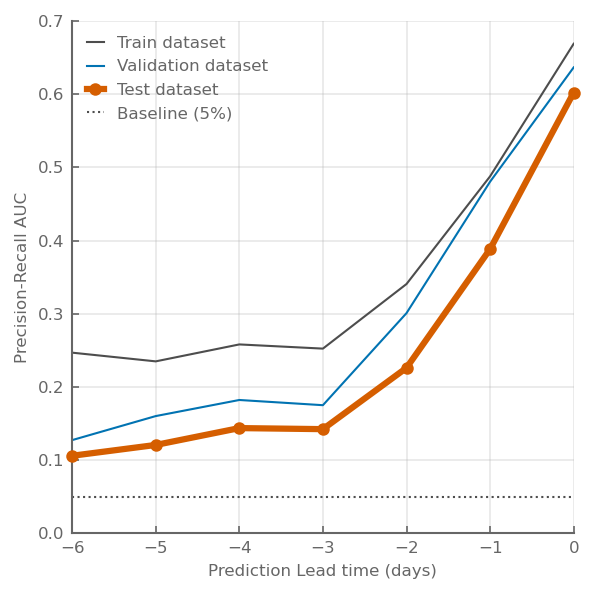

In [123]:
auc_train = []
auc_val = []
auc_test = []

for k in range(7):
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.dataset=='train').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.dataset=='train').predictions.dropna('time')[:,k])
    auc_train.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.dataset=='val').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.dataset=='val').predictions.dropna('time')[:,k])
    auc_val.append(sklearn.metrics.auc(r,p))
    p,r,threshold = sklearn.metrics.precision_recall_curve(ds_predictions.where(ds_predictions.dataset=='test').targets.dropna('time')[:,k], ds_predictions.where(ds_predictions.dataset=='test').predictions.dropna('time')[:,k])
    auc_test.append(sklearn.metrics.auc(r,p))

fig, ax = plt.subplots(figsize=(4,4,))

ax.plot(np.arange(0,-7,-1),auc_train, color='.3', label='Train dataset')
ax.plot(np.arange(0,-7,-1),auc_val, label='Validation dataset')
ax.plot(np.arange(0,-7,-1),auc_test, color='C3', lw=3, label='Test dataset', marker='o', markersize=5, clip_on=False, zorder=100)
ax.grid(ls='-', alpha=.3)
ax.axhline(0.05,color='.3' , label='Baseline (5%)', ls=':')
ax.set_xlim(-6,0)
ax.set_ylim(0,0.7)
ax.legend()
ax.set_ylabel('Precision-Recall AUC')
ax.set_xlabel('Prediction Lead time (days)')
plt.tight_layout()
plt.savefig('plots/model_skill_PR-AUC.svg', dpi=300, transparent=True)

# Plot 1: attributions are aggregated

<Axes: ylabel='Frequency'>

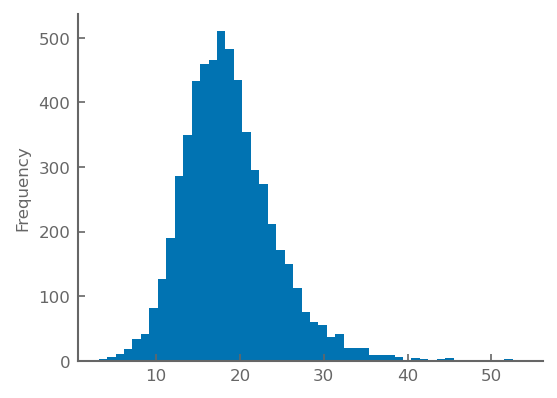

In [138]:
((ds_attrs.lrp_normed.max(['x','y'])-ds_attrs.lrp_normed.mean(['x','y']))/ds_attrs.lrp_normed.std(['x','y'])).to_series().plot.hist(bins=50, logy=False)

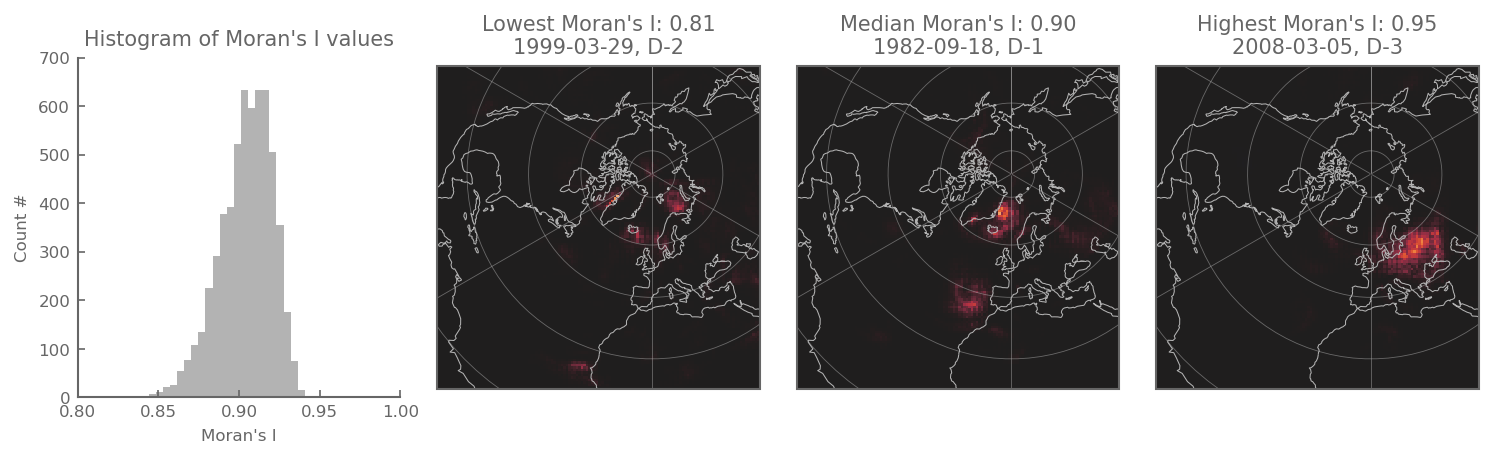

In [6]:
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax().values)
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmin().values)
fig, axs = plt.subplot_mosaic("""ABCD""", figsize=(10,3), 
                              per_subplot_kw=dict(BCD=dict(projection=proj)))
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax()

ds_attrs.moran_I.plot.hist(ax=axs['A'], bins=30, color='.7')
ds_attrs.sel(time_of_event='2018-08-10', timestep_past=-2).lrp_normed.plot(ax=axs['B'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.005)
ds_attrs.sel(time_of_event='1982-09-18', timestep_past=-1).lrp_normed.plot(ax=axs['C'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.005)
ds_attrs.sel(time_of_event='2008-03-05', timestep_past=-3).lrp_normed.plot(ax=axs['D'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.005)


lowest_moran = ds_attrs.sel(time_of_event='2018-08-10', timestep_past=-2).moran_I.values
median_moran = ds_attrs.sel(time_of_event='1982-09-18', timestep_past=-1).moran_I.values
highest_moran = ds_attrs.sel(time_of_event='2008-03-05', timestep_past=-3).moran_I.values

for letter in 'BCD':
    # axs[letter].coastlines(color='.7', lw=.4, alpha=.5)
    add_grid_coastlines(axs[letter])
axs['A'].set_title('Histogram of Moran\'s I values')
# axs['A'].set(ylim=(0,700))
axs['A'].set(xlabel="Moran's I", ylabel='Count #', xlim=(.8,1.), ylim=(0,700))
axs['B'].set_title(f'Lowest Moran\'s I: {lowest_moran:.02f}\n1999-03-29, D-2')
axs['C'].set_title(f'Median Moran\'s I: {median_moran:.02f}\n1982-09-18, D-1')
axs['D'].set_title(f'Highest Moran\'s I: {highest_moran:.02f}\n2008-03-05, D-3')
plt.tight_layout()
plt.savefig('plots/moranI_examples_lrp_normed_v2.png', dpi=300, transparent=True)

# Plot 2: example to get to patchs and cyclones

In [139]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi


def get_gdf_from_segment_grid(segments):
    x = segments.x.values
    y = segments.y.values
    labels = segments.values
    dx = float(np.mean(np.diff(x))) 
    dy = float(np.mean(np.diff(y))) 
    x0 = x.min() - dx / 2.0
    y0 = y.min() - dy / 2.0  
    transform = Affine.translation(x0, y0) * Affine.scale(dx, dy)
    geoms = []
    vals = []
    for geom, value in features.shapes(labels, transform=transform):
        if value == 0:
            continue
        geoms.append(shape(geom))
        vals.append(value)
    gdf_segments = gpd.GeoDataFrame(
        {"label": vals},
        geometry=geoms,
        crs="EPSG:3413"   # or "EPSG:3995" or your custom proj string
    )
    gdf_segments= gdf_segments.set_index('label') 
    gdf_segments=gdf_segments.reset_index().dissolve(by='label')
    return gdf_segments

def segments_from_attribution_grid_watershed(time_of_event, timestep_past, abs_threshold = 0.0005, rolling=5):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    data = data.rio.write_crs(proj) 
    img = data.rolling(x=rolling, y=rolling, center=True).mean()
    img_filter = img.where(np.abs(img)>abs_threshold).fillna(0)
    img_filter = np.abs(img_filter)
    coords = peak_local_max(img_filter.values)
    mask = np.zeros(img.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-np.abs(img), markers, mask=img)
    patch_labels = xr.DataArray(labels, dims=img.dims, coords=img.coords)
    # plt.imshow(labels)
    # plt.imshow(img.where(np.abs(img)>abs_threshold))
    patch_labels = patch_labels.where(np.abs(img)>abs_threshold)
    attributions = img.groupby(patch_labels).sum()

    gdf_patches = get_gdf_from_segment_grid(patch_labels)
    gdf_patches['patch_attributions'] = attributions.values
    gdf_patches['patch_area'] = gdf_patches.geometry.area/1_000_000
    gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117000/117000)
    X_values = [img.x[coords[k,1]].values for k in range(gdf_patches.index.size)]
    Y_values = [img.y[coords[k,0]].values for k in range(gdf_patches.index.size)]
    gdf_patches['location_local_max'] = gpd.points_from_xy(X_values, Y_values, crs=proj)
    return gdf_patches, data

def segments_from_attribution_grid_watershed_v2(time_of_event, timestep_past, ds_attrs,abs_threshold = 0.0005, rolling=5):
    data = ds_attrs.sel(time_of_event=time_of_event,timestep_past=timestep_past).lrp_normed
    data = data.rio.write_crs(proj) 
    img = data.rolling(x=rolling, y=rolling, center=True).mean()
    img_filter = img.where(np.abs(img)>abs_threshold).fillna(0)
    img_filter = np.abs(img_filter)
    distance = ndi.distance_transform_edt(img_filter>0)
    peaks = peak_local_max(
    distance,
    min_distance=4,
    labels=img_filter>0
    )
    markers = np.zeros_like(img, dtype=int)
    for i, (r, c) in enumerate(peaks, start=1):
        markers[r, c] = i

    labels = watershed(-distance, markers, mask=img_filter>0)
    patch_labels = xr.DataArray(labels, dims=img.dims, coords=img.coords)
    patch_labels = patch_labels.where(labels>0)
    
    attributions = img.groupby(patch_labels).sum()

    gdf_patches = get_gdf_from_segment_grid(patch_labels)
    gdf_patches['patch_attributions'] = attributions.values
    gdf_patches['patch_area'] = gdf_patches.geometry.area/1_000_000
    gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117000/117000)
    # X_values = [img.x[coords[k,1]].values for k in range(gdf_patches.index.size)]
    # Y_values = [img.y[coords[k,0]].values for k in range(gdf_patches.index.size)]
    # gdf_patches['location_local_max'] = gpd.points_from_xy(X_values, Y_values, crs=proj)
    return gdf_patches, data

def get_cyclones_for_day(time_of_event, timestep_past):
    time = pd.to_datetime(time_of_event) + pd.Timedelta(f'{timestep_past}D')
    cyclones_gdf_day = cyclones_gdf.loc[time.strftime("%Y-%m-%d")]
    return cyclones_gdf_day.set_index('track_id')

def get_top_cycs_area_overlap(series):
        geom = gpd.GeoDataFrame(geometry=series)
        if np.isnan(geom.area.max()):
            return np.nan
        else:
            return geom.area.idxmax()

def get_best_cycs_per_distance(series):
    cycs_available_index = series.dropna().index
    if len(cycs_available_index) == 0:
        return np.nan
    cycs_available = cyclones_gdf_day.loc[cycs_available_index].geometry
    dist = cycs_available.distance(gdf_patches.loc[series.name].location_local_max)
    return dist.idxmax()

def attribution_patches_to_cyclones(gdf_patches,cyclones_gdf_day, buffer=500_000):
    geom = gdf_patches.geometry.apply(lambda g: cyclones_gdf_day.buffer(buffer).intersection(g).loc[cyclones_gdf_day.buffer(buffer).intersects(g)])
    track_id = geom.apply(get_top_cycs_area_overlap, axis=1)
    gdf_patches['cyclone_track_id'] = track_id.values
    gdf_patches['patch_area'] = gdf_patches.area
    gdf_patches['patch_pixel_count'] = np.round(gdf_patches.patch_area/117000/117000)
    gdf_patches = gdf_patches
    return gdf_patches

def group_cyclones(gdf_patches):
    cyclone_groups = gdf_patches.groupby('cyclone_track_id')[['patch_attributions','patch_area','patch_pixel_count']].sum()
    gdf_patches_cyclones = gpd.GeoDataFrame(cyclone_groups, geometry = gdf_patches.dissolve(by='cyclone_track_id').geometry)
    gdf_patches_cyclones['patch_area'] = gdf_patches_cyclones.area
    gdf_patches_cyclones['patch_pixel_count'] = np.round(gdf_patches_cyclones.patch_area/117000/117000)    
    gdf_patches_cyclones = gdf_patches_cyclones.reset_index()
    gdf_no_cycs = gdf_patches.loc[gdf_patches.cyclone_track_id.isnull()][gdf_patches_cyclones.columns]
    if gdf_no_cycs.index.size>0:
        gdf_patches_cyclones = pd.concat([gdf_patches_cyclones, gdf_no_cycs])
    return gdf_patches_cyclones



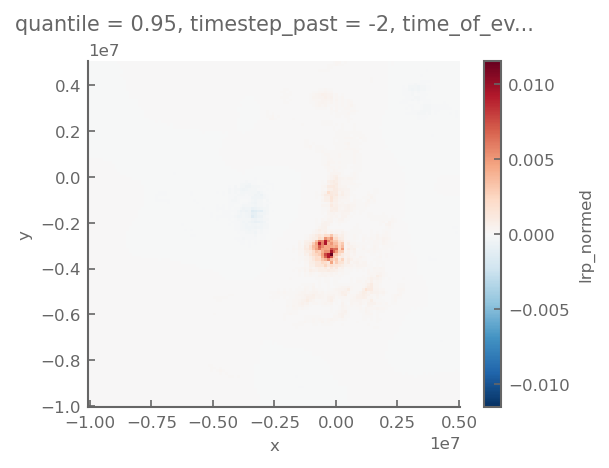

In [151]:
attributions_day.plot()


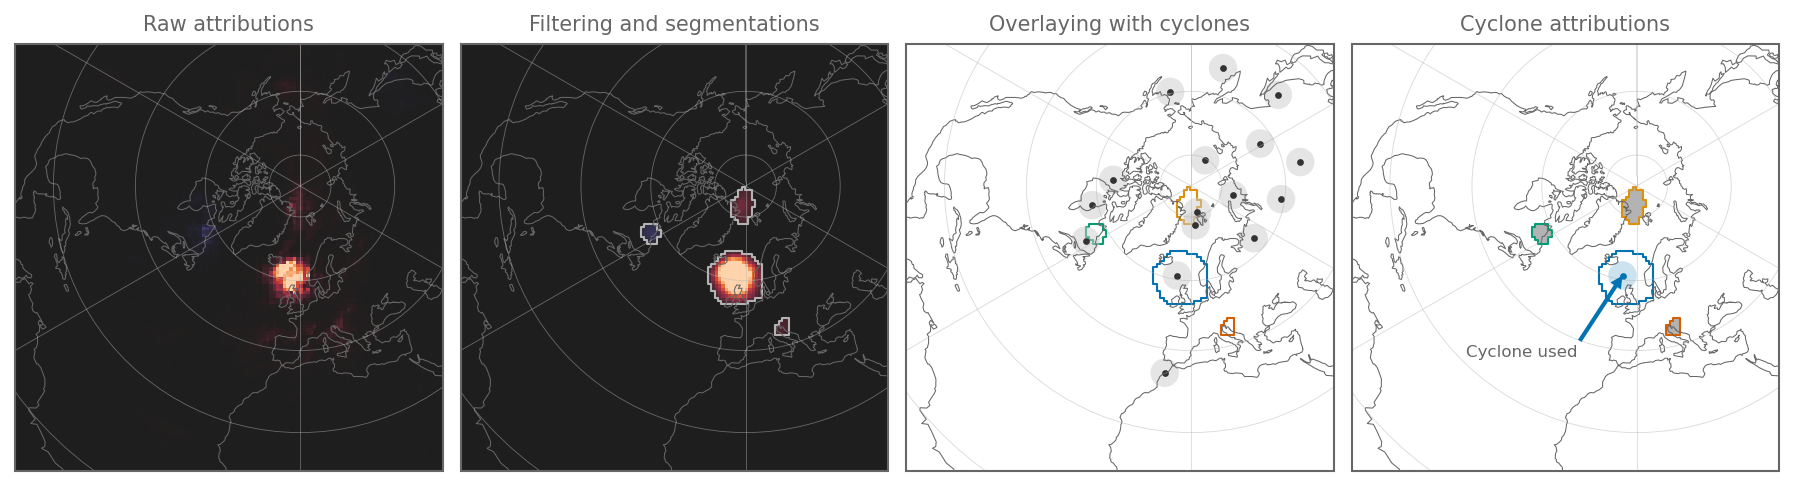

In [203]:
fig, axs = plt.subplot_mosaic("""ABCD""",figsize=(12,4), per_subplot_kw=dict(ABCD=dict(projection=proj)))
time_of_event = '2016-08-09'
timestep_past=-2



attributions_day = ds_attrs.lrp_normed.sel(time_of_event=time_of_event, timestep_past=timestep_past)
gdf_day = gdf_cyclones.set_index(['time_of_event','timestep_past']).loc[time_of_event,timestep_past]
cyclones_day = all_cyclones.set_index('date').loc[(pd.to_datetime(time_of_event) + pd.Timedelta('1D')*timestep_past).strftime("%Y-%m-%d")].set_index('track_id')

attributions_day.plot(cmap='icefire', ax=axs['A'], transform=proj, add_colorbar=False, vmax=0.005)

rolling=5
abs_threshold=0.0005
gdf_patches, data = segments_from_attribution_grid_watershed_v2(time_of_event,timestep_past,ds_attrs, abs_threshold = 0.0005, rolling=5)
img = data.rolling(x=rolling, y=rolling, center=True).mean()
img_filter = img.where(np.abs(img)>abs_threshold).fillna(0)
# img_filter = np.abs(img_filter)

img_filter.plot(ax=axs['B'], cmap='icefire', vmin=-0.003, add_colorbar=False)
gdf_day.plot(ax=axs['B'], transform=proj, color='none',   edgecolor='.7')

gdf_day.plot(ax=axs['C'], transform=proj, color='none',   edgecolor=sns.color_palette('colorblind', as_cmap=True))
# img_filter.plot(ax=axs['C'], cmap='icefire', vmin=-0.005, add_colorbar=False)
cyclones_day.geometry.buffer(500_000).plot(aspect=1, ax=axs['C'], transform=proj, color='.8', alpha=.5)
cyclones_day.geometry.plot(aspect=1, ax=axs['C'], transform=proj, markersize=5, color='.2')

# img_filter.plot(ax=axs['D'], cmap='icefire', vmin=-0.005, add_colorbar=False)

gdf_day.iloc[:1].plot(ax=axs['D'], transform=proj, color='none',   edgecolor=sns.color_palette('colorblind'))
gdf_day.iloc[1:].plot(ax=axs['D'], transform=proj, color='.7',   edgecolor=sns.color_palette('colorblind')[1:])


cyclones_day.loc[gdf_day.cyclone_track_id.dropna()[:1]].geometry.buffer(500_000).plot(aspect=1, ax=axs['D'], transform=proj, edgecolor='none', color=sns.color_palette('colorblind'),alpha=.2,linewidth=2)
cyclones_day.loc[gdf_day.cyclone_track_id.dropna()[:1]].geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color=sns.color_palette('colorblind'))
# # cyclones_day.geometry.plot(aspect=1, ax=axs['C'], transform=proj, markersize=5, color='.2')
# cyclones_day.loc[gdf_day.cyclone_track_id.dropna()].geometry.plot(aspect=1, ax=axs['D'], transform=proj, markersize=5, color='.2')


axs['D'].annotate('Cyclone used', xy=cyclones_day.loc[gdf_day.cyclone_track_id.dropna()].iloc[0][['x','y']].values, xytext=(-6e6, -6e6),
            arrowprops=dict(facecolor='C0', edgecolor='none', width=2, headwidth=6, headlength=6),
            )

for letter in axs:
    add_grid_coastlines(axs[letter])
    axs[letter].set_extent((-1e7, 5e6, -1e7, 5e6), crs=proj)
    axs[letter].set_title('')
axs['A'].set_title('Raw attributions')
axs['B'].set_title('Filtering and segmentations')
axs['C'].set_title('Overlaying with cyclones')
axs['D'].set_title('Cyclone attributions')
plt.tight_layout()

# Plot 3.0: patches distribution


/tmp/ipykernel_2568871/341005443.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.patch_pixel_count, np.arange(0,1001,10)),


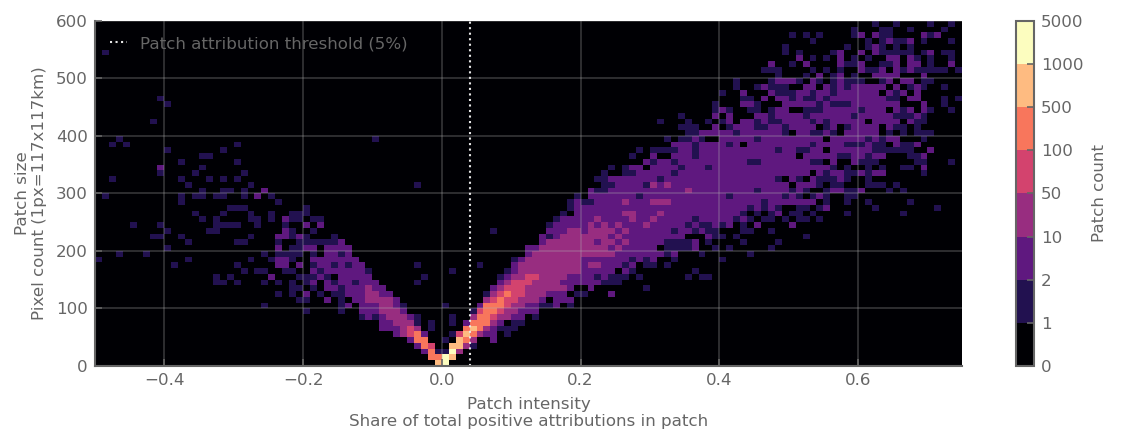

In [239]:
fig, ax = plt.subplots(figsize=(8,3))
df_plot = gdf_cyclones.groupby([pd.cut(gdf_cyclones.patch_pixel_count, np.arange(0,1001,10)),
                      pd.cut(gdf_cyclones.patch_attributions, np.arange(-1.5,1.1, .01)),
                      ]).geometry.count().to_xarray().rename('Patch count')
# df_plot['patch_attributions'] = df_patch.patch_attributions*100
df_plot.where(df_plot>=1).fillna(0).plot( vmin=1, cmap='magma', levels=[0,1,2,10,50, 100,500, 1000,5000], rasterized=True,)
ax.grid(linestyle='-', alpha=.3, zorder=10)
ax.set(ylim=(0,600), xlim=(-.5,.75))
# ax.set_ylim(0,50)
ax.set_ylabel('Patch size\nPixel count (1px=117x117km)')
ax.set_xlabel('Patch intensity\nShare of total positive attributions in patch')
ax.axvline(0.04, color='.9', ls=':', label='Patch attribution threshold (5%)',)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plots/patches_distributions.svg', dpi=300, transparent=True)

# Plot 3: there are usually 1-3 large patchs per prediction
"Large patchs" are defined as 25pixels minimum (5x5 square)

In [224]:
categories = np.array(['                     ' for k in gdf_cyclones.index])
categories[((gdf_cyclones.patch_pixel_count<25)).values] = 'small patch'
categories[((np.abs(gdf_cyclones.patch_attributions)<.1)&(gdf_cyclones.patch_pixel_count>=25)).values] = 'large neutral'
categories[((gdf_cyclones.patch_attributions<-.1)&(gdf_cyclones.patch_pixel_count>=25)).values] = 'large negative'
categories[((gdf_cyclones.patch_attributions>.1)&(gdf_cyclones.patch_pixel_count>=25)).values] = 'large positive'
gdf_cyclones['patch_category'] = categories
# gdf_cyclones.category.value_counts().plot.bar()

In [48]:
df_plot = gdf_cyclones.query("patch_category=='large positive' ").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')

df_plot.idxmax()

(Timestamp('1979-12-27 00:00:00'), np.int32(-1))

<Axes: >

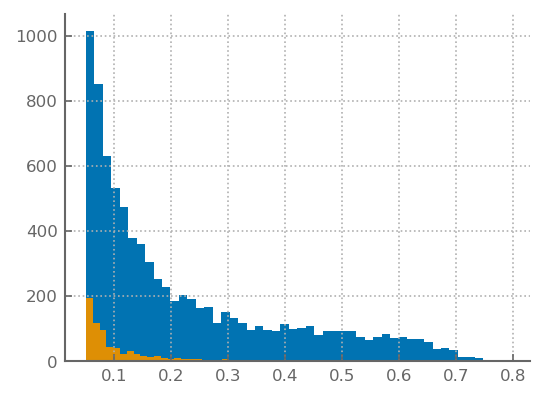

In [276]:
gdf_cyclones.query("(patch_attributions>.05)&(is_cyclone)").patch_attributions.hist(bins=50)
gdf_cyclones.query("(patch_attributions>.05)&(not is_cyclone)").patch_attributions.hist(bins=50)

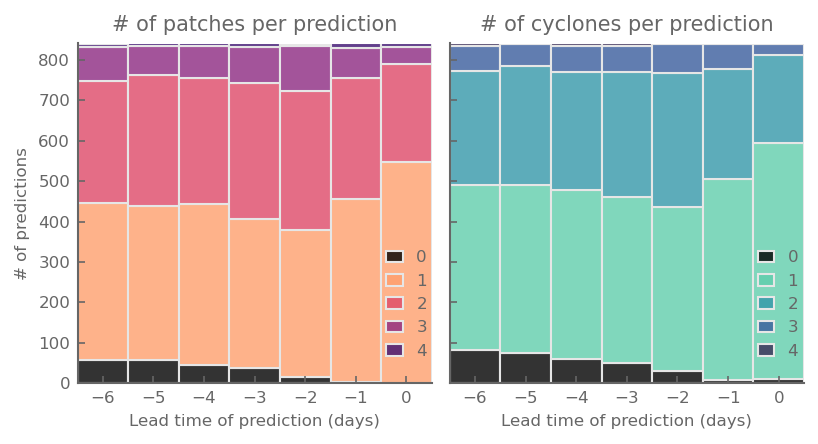

In [354]:
df_plot = gdf_cyclones.query("patch_attributions>0.05 ").groupby(['time_of_event','timestep_past']).geometry.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot.index] =df_plot
df_plot = df_count_all.reset_index()

df_plot2 = gdf_cyclones.query("(patch_attributions>.05) & (is_cyclone)").groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')
df_count_all = gdf_cyclones.groupby(['time_of_event','timestep_past']).cyclone_track_id.count().rename('count')*0
df_count_all.loc[df_plot2.index] =df_plot2
df_plot2 = df_count_all.reset_index()

fig, axs =plt.subplots(1,2,figsize=(5.5,3), )

f1 = (so.Plot(df_plot, x='timestep_past', color='count')
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Count(),so.Stack(), legend=True)
 .scale(color=so.Nominal(['0']+list(sns.color_palette('magma_r', n_colors=4)), order=[0,1,2,3,4], ) )
 .layout(size=(4,4))
 .limit(x=(-6.5,0.5), y=(0,840))
 .label(title='# of patches per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive patchs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).on(axs[0]).plot()


f2 = (so.Plot(df_plot2, x='timestep_past', color='count')
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Count(),so.Stack(), legend=True)
 .scale(color=so.Nominal(['0']+list(sns.color_palette('mako_r', n_colors=4)), order=[0,1,2,3,4], ) )
 .layout(size=(4,4))
 .limit(x=(-6.5,0.5), y=(0,840))
 .label(title='# of cyclones per prediction', y='# of predictions', x='Lead time of prediction (days)', legend='Number of large positive patchs')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 ).on(axs[1]).plot()
fig.legends[0].set_bbox_to_anchor((0.45, 0.31))
fig.legends[0].set_title('')
fig.legends[1].set_bbox_to_anchor((0.90, 0.31))
fig.legends[1].set_title('')
axs[1].set_yticklabels([])
axs[1].set_ylabel('')
plt.tight_layout()

fig.savefig('plots/N_large_positive_patches_per_predictions.png', dpi=300, transparent=True)

# plt.savefig('plots/N_large_patches_per_predictions.png', dpi=300, transparent=True)

In [303]:
gdf_cyclones.query('patch_attributions>0.05').groupby('is_cyclone').geometry.count()/gdf_cyclones.query('patch_attributions>0.05').groupby('is_cyclone').geometry.count().sum()

is_cyclone
False    0.071916
True     0.928084
Name: geometry, dtype: float64

# Cyclones are in the right place
need map here

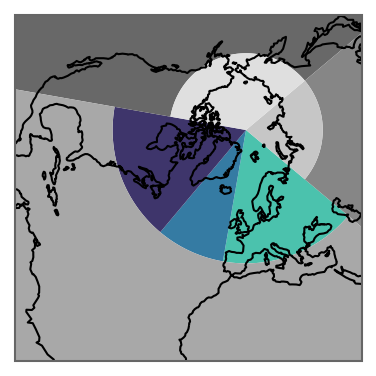

In [433]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(subplot_kw=dict(projection=proj))

ax.coastlines()
ax.set_extent((-1e7, 5e6, -1e7, 5e6), crs=proj)
import numpy as np
from shapely.geometry import Polygon
import shapely
# from shapely.ops import cascaded_union

def get_polygon(lon_min, lon_max, lat_min, lat_max,
                polygon_kwargs = dict(closed=True, facecolor='orange', alpha=0.5)):
    points_lon = list(np.linspace(lon_min, lon_max, 100)) + [lon_max for k in range(100)] + list(np.linspace(lon_max, lon_min, 100)) + [lon_min for k in range(100)]
    points_lat =  [lat_min for k in range(100)] + list(np.linspace(lat_min, lat_max, 100)) + [lat_max for k in range(100)]+ list(np.linspace(lat_max, lat_min, 100))
    vertices = list(zip(points_lon, points_lat))
    polygon_patch = mpatches.Polygon(vertices, transform=ccrs.PlateCarree(), **polygon_kwargs)
    return polygon_patch



def get_shapely_polygon(lon_min, lon_max, lat_min, lat_max,):
    points_lon = list(np.linspace(lon_min, lon_max, 100)) + [lon_max for k in range(100)] + list(np.linspace(lon_max, lon_min, 100)) + [lon_min for k in range(100)]
    points_lat =  [lat_min for k in range(100)] + list(np.linspace(lat_min, lat_max, 100)) + [lat_max for k in range(100)]+ list(np.linspace(lat_max, lat_min, 100))
    
    vertices = list(zip(points_lon, points_lat))
    polygon = Polygon(vertices, )
    return polygon

def get_shapely_polygon_from_points(p1, p2, p3, p4, n=100):
    points = []
    corners = [p1, p2, p3, p4, p1]  # close the loop
    for (x0, y0), (x1, y1) in zip(corners[:-1], corners[1:]):
        xs = np.linspace(x0, x1, n, endpoint=False)
        ys = np.linspace(y0, y1, n, endpoint=False)
        points.extend(zip(xs, ys))
    return Polygon(points)


# NAm = get_shapely_polygon(-100,-120,30,90,)
WestAtl = get_shapely_polygon(-40,-100,40,90)
EastAtl = get_shapely_polygon(-10,-40,40,90)
Tropics = get_shapely_polygon(-100,50,-10,40)


Arctic1 = get_shapely_polygon(130,360-100,60,90)
# Arctic2 = get_shapely_polygon(0,360,80,90)

ArcticAsia = get_shapely_polygon(130,50,60,90)
Pacific1 = get_shapely_polygon(130,360-100,0,60)
# Pacific2 = get_shapely_polygon(-100,-110,0,30)

Asia = get_shapely_polygon(130,50,0,60)
# Norge = get_shapely_polygon(-10,50,50,80)
Europe = get_shapely_polygon(-10,50,40,90)


gdf_sectors = gpd.GeoDataFrame(geometry=[
                                 Europe,
                                 EastAtl,
                                 WestAtl,
                                 Pacific1,
                                 Asia,
                                 Tropics,
                                 ArcticAsia,
                                 Arctic1,
                                 # Norge,
                                 ], 
                        index = [
                                'Europe',
                                'East Atlantic',
                                'West Atlantic',
                                'Pacific',
                                'Asia',
                                'Tropics',
                                'Arctic Asia',
                                'Arctic Pacific',
                                # 'Norway',
                                ],         
                        crs=ccrs.PlateCarree())

palette = sns.color_palette(sns.color_palette('Greys',8)[1:6] + sns.color_palette('mako',3)[-3:])
palette
gdf_sectors['color'] = palette[::-1]

gdf_sectors.plot(ax=ax, transform=ccrs.PlateCarree(), legend=True, color=gdf_sectors.color)

from shapely.geometry import Point
geometry = [Point(xy) for xy in zip(gdf_cyclones.cyclone_lon, gdf_cyclones.cyclone_lat)]

# create GeoDataFrame
gdf_cyclones_center = gpd.GeoDataFrame(
    geometry=geometry,
    crs="EPSG:4326"   # WGS84 lon/lat
)
cyclones_with_sector = gpd.sjoin(
    gdf_cyclones_center.to_crs(proj),
    gdf_sectors.to_crs(proj),
    how="left",
    predicate="within"   # or "intersects" if needed
)
gdf_cyclones['cyclone_region'] = cyclones_with_sector.index_right


# gdf_cyclones

/tmp/ipykernel_2568871/3794036910.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_all_counts.cyclone_msl[df_all_counts.cyclone_msl>0] = np.nan
/tmp/ipykernel_2568871/3794036910.py:6: SettingWithCopyWarning: 
A value is trying to be se

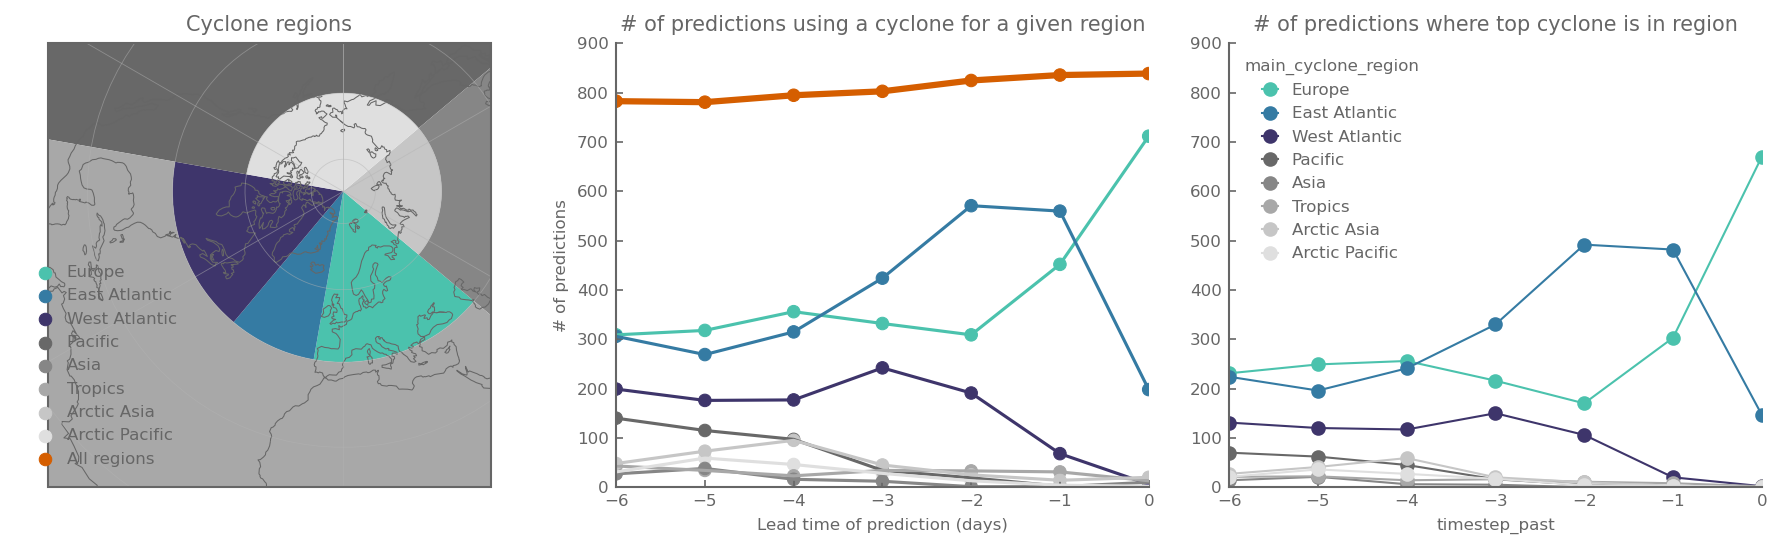

In [495]:
df_counts = gdf_cyclones.reset_index().query("patch_attributions>0.05").groupby(['time_of_event','timestep_past','cyclone_region']).cyclone_msl.count().reset_index()
df_counts = df_counts.query("cyclone_msl>0")
df_all_counts = gdf_cyclones.reset_index().query("patch_attributions>0.05").groupby(['time_of_event','timestep_past']).cyclone_msl.count().reset_index()
df_all_counts['cyclone_region'] = 'All regions'
df_all_counts = df_all_counts
df_all_counts.cyclone_msl[df_all_counts.cyclone_msl>0] = np.nan
df_counts = pd.concat([df_counts, df_all_counts])

fig, axs = plt.subplot_mosaic("""ABC""",figsize=(12,3.7), per_subplot_kw=dict(A=dict(projection=proj)))


gdf_sectors.plot(ax=axs['A'], transform=ccrs.PlateCarree(), legend=True, color=gdf_sectors.color)
add_grid_coastlines(axs['A'])
axs['A'].set_title('Cyclone regions')
axs['A'].set_extent((-1e7, 5e6, -1e7, 5e6), crs=proj)
f1 = (so.Plot(df_counts, x='timestep_past', color='cyclone_region', linewidth='cyclone_region', y='timestep_past')
 .add(so.Lines(), so.Count(),  legend=False,)
 .add(so.Dot(), so.Count(), )
 .scale(color=so.Nominal(list(gdf_sectors.color.values) +['C3'],
                         order=list(gdf_sectors.index)+['All regions']),
       linewidth=so.Nominal([1.5 for k in gdf_sectors.index] + [3],
                            order=list(gdf_sectors.index)+['All regions']),
       )

 .layout(size=(4,4))
  .limit(x=(-6,0), y=(0,900))
 .label(title='# of predictions using a cyclone for a given region')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 .label(legend="Measurement", y='# of predictions', x='Lead time of prediction (days)')
 ).on(axs['B']).plot()#.save('plots/cyclone_area.svg', dpi=300, transparent=True)

fig.legends[0].set_bbox_to_anchor((0.012, 0.33))
fig.legends[0].set_title('')
top_cycs.fillna('No cyclone').groupby(['timestep_past','main_cyclone_region']).size().unstack().fillna(0)[gdf_sectors.index].plot(ax=axs['C'], color=gdf_sectors.color, marker='o')
axs['C'].set(title='# of predictions where top cyclone is in region', xlim=(-6,0), ylim=(0,900))
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
plt.tight_layout()

In [489]:
top_cycs

,time_of_event,timestep_past,main_cyclone_region
0,1979-01-07,-6,NaN
1,1979-01-07,-5,Europe
2,1979-01-07,-4,West Atlantic
3,1979-01-07,-3,West Atlantic
4,1979-01-07,-2,East Atlantic
...,...,...,...
5875,2024-12-29,-4,East Atlantic
5876,2024-12-29,-3,East Atlantic
5877,2024-12-29,-2,East Atlantic
5878,2024-12-29,-1,Europe


In [474]:
gdf_cyclones.reset_index()

,level_0,index,cyclone_track_id,patch_attributions,patch_area,patch_pixel_count,time_of_event,timestep_past,is_cyclone,cyclone_date,patch_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y,cyclone_region,geometry
0,0,1979-01-01 63,63.0,0.029056,6.417013e+11,47.0,1979-01-07,-6,True,1979-01-01,large neutral,1979-01-01 63,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,Europe,"POLYGON ((925196.85 -5807086.614, 925196.85 -5..."
1,1,1979-01-01 95,95.0,0.017663,4.045508e+11,30.0,1979-01-07,-6,True,1979-01-01,large neutral,1979-01-01 95,98798.766080,34.344986,47.073222,2.748557e+06,-4.022446e+06,Europe,"POLYGON ((3051181.102 -4507874.016, 3051181.10..."
2,2,1979-01-02 0,NaN,0.125624,2.148304e+12,157.0,1979-01-07,-6,False,1979-01-01,large positive,None,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((688976.378 3169291.339, 688976.378 3..."
3,3,1979-01-02 0,NaN,0.012944,3.208506e+11,23.0,1979-01-07,-6,False,1979-01-01,small patch,None,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((2578740.157 -5334645.669, 2578740.15..."
4,4,1979-01-02 0,NaN,0.003119,8.370017e+10,6.0,1979-01-07,-6,False,1979-01-01,small patch,None,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((2460629.921 3405511.811, 2460629.921..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24808,24808,2024-12-28 955745,955745.0,0.015510,3.766508e+11,28.0,2024-12-29,-1,True,2024-12-28,large neutral,2024-12-28 955745,97774.399016,51.367366,75.020342,1.274580e+06,-1.018673e+06,Arctic Asia,"POLYGON ((1161417.323 -1673228.346, 1161417.32..."
24809,24809,2024-12-28 955824,955824.0,0.186023,1.799554e+12,131.0,2024-12-29,-1,True,2024-12-28,large positive,2024-12-28 955824,98269.606412,-9.323234,70.095391,-3.527292e+05,-2.148525e+06,Europe,"POLYGON ((-1200787.402 -3444881.89, -1200787.4..."
24810,24810,2024-12-28 955857,955857.0,0.006150,1.534503e+11,11.0,2024-12-29,-1,True,2024-12-28,small patch,2024-12-28 955857,102386.158785,-13.644221,48.365849,-1.111436e+06,-4.578660e+06,East Atlantic,"POLYGON ((-1555118.11 -4507874.016, -1555118.1..."
24811,24811,2024-12-28 955944,955944.0,0.340379,2.790006e+12,204.0,2024-12-29,-1,True,2024-12-28,large positive,2024-12-28 955944,97605.196759,11.612191,73.716337,3.573750e+05,-1.739116e+06,Europe,"POLYGON ((-374015.748 -3444881.89, -374015.748..."


In [475]:
def find_top_cyc(df):
    out = df.query("cyclone_track_id != 'No cyclone' &patch_attributions>0.05")
    if out.index.size==0:
        return 'No cyclone'
    else:
        return out.iloc[out.patch_attributions.argmax()].cyclone_region

top_cycs = gdf_cyclones.reset_index().groupby(['time_of_event','timestep_past']).apply(
    find_top_cyc
)
top_cycs = top_cycs.rename('main_cyclone_region').reset_index()#.fillna('No cyclone')


/tmp/ipykernel_2568871/3780471573.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cycs = gdf_cyclones.reset_index().groupby(['time_of_event','timestep_past']).apply(


In [ ]:
t#.sum(axis=1)#.plot()#.reset_index().rename(columns={0:'count'})

main_cyclone_region,Arctic Asia,Arctic Pacific,Asia,East Atlantic,Europe,No cyclone,Pacific,Tropics,West Atlantic
timestep_past,,,,,,,,,
-6,27.0,21.0,14.0,224.0,231.0,101.0,70.0,21.0,131.0
-5,41.0,36.0,21.0,196.0,249.0,93.0,62.0,22.0,120.0
-4,59.0,27.0,6.0,241.0,256.0,75.0,45.0,14.0,117.0
-3,20.0,17.0,5.0,330.0,216.0,70.0,16.0,16.0,150.0
-2,10.0,4.0,0.0,492.0,170.0,42.0,5.0,11.0,106.0
-1,3.0,3.0,0.0,482.0,303.0,20.0,1.0,8.0,20.0
0,0.0,0.0,0.0,147.0,670.0,19.0,0.0,2.0,2.0


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/properties.py:130: UserWarning: The color list has more values (11) than needed (10), which may not be intended.
  warnings.warn(message, UserWarning)


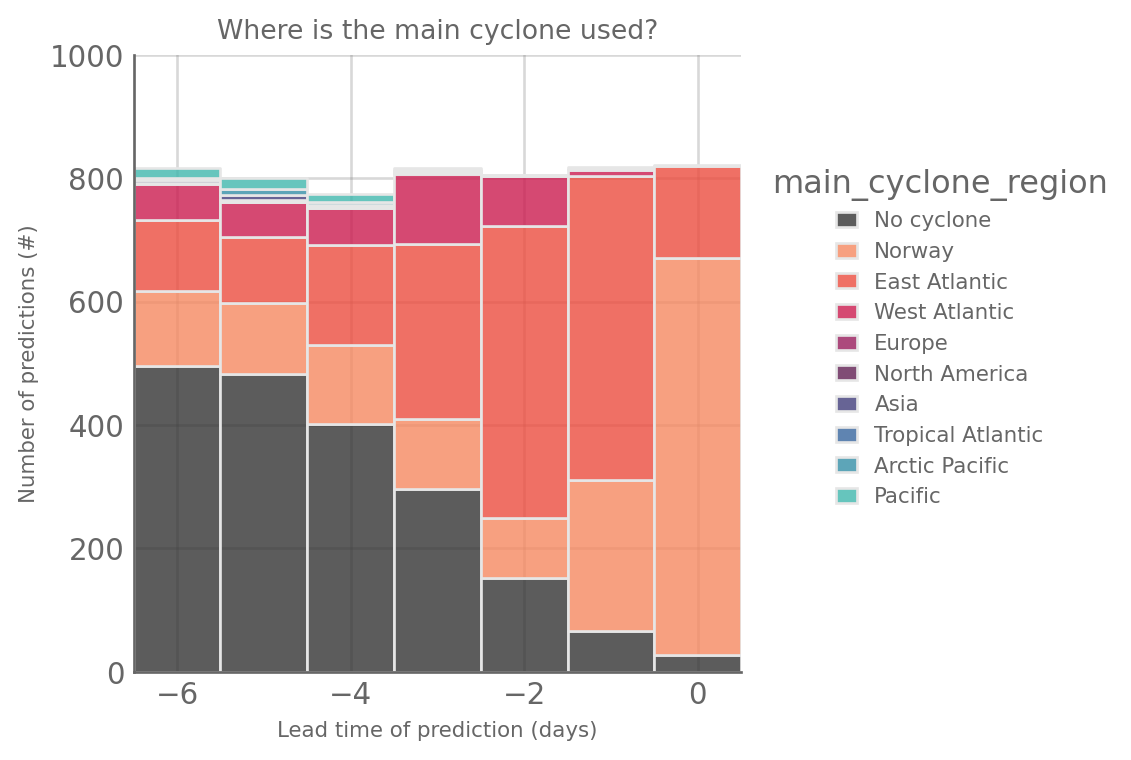

In [37]:

df_count = top_cycs.groupby(['timestep_past','main_cyclone_region']).time_of_event.count().rename('count').unstack().fillna(0).stack().reset_index().rename(columns={0:'count'})
df_count['main_cyclone_region'] = pd.Categorical(df_count["main_cyclone_region"], categories=['No cyclone',
                                'Norway','East Atlantic','West Atlantic' ,'Europe',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific', 
                                ], ordered=True)
(so.Plot(df_count.sort_values('main_cyclone_region'), x='timestep_past', color='main_cyclone_region',y='count')
 .add(so.Bars(alpha=.8, width=1, edgecolor='.9'), so.Stack(), legend=True)
  .scale(color=so.Nominal(['.2']+ palette,
                         order=['No cyclone',
                                'Norway','East Atlantic','West Atlantic' ,'Europe',
                                 'North America','Asia','Tropical Atlantic','Arctic Pacific','Pacific', 
                                ]))


 .layout(size=(4,4))
  .limit(x=(-6.5,0.5), y=(0,1000))
 .label(title='Where is the main cyclone used?')
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 .label(legend="Measurement", x='Lead time of prediction (days)', y='Number of predictions (#)')
 )
#.plot().save('plots/cyclone_area.svg', dpi=300, transparent=True)


# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)
# so.Norm(func=lambda x:937, percent=True)


In [18]:
df_counts.query('timestep_past==-6').groupby(['cyclone_region']).timestep_past.count().sort_values(ascending=False).iloc[1:]

cyclone_region
Atlantic North West    586
Atlantic North East    473
Arctic Eurasia         108
Pacific                 97
Tropical Atlantic       65
Arctic Pacific          52
Eurasia                 42
Name: timestep_past, dtype: int64

In [16]:
gdf_cyclones.time_of_event.unique()

<DatetimeArray>
['1979-01-07 00:00:00', '1979-03-03 00:00:00', '1979-03-04 00:00:00',
 '1979-03-05 00:00:00', '1979-08-14 00:00:00', '1979-09-11 00:00:00',
 '1979-09-13 00:00:00', '1979-09-17 00:00:00', '1979-09-18 00:00:00',
 '1979-09-19 00:00:00',
 ...
 '2024-10-23 00:00:00', '2024-10-22 00:00:00', '2024-10-27 00:00:00',
 '2024-10-31 00:00:00', '2024-11-16 00:00:00', '2024-12-01 00:00:00',
 '2024-12-13 00:00:00', '2024-12-15 00:00:00', '2024-12-18 00:00:00',
 '2024-12-29 00:00:00']
Length: 928, dtype: datetime64[ms]

/tmp/ipykernel_2254762/3437575887.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_patch_cycs.groupby(["timestep_past","time_of_event",
/tmp/ipykernel_2254762/3437575887.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()


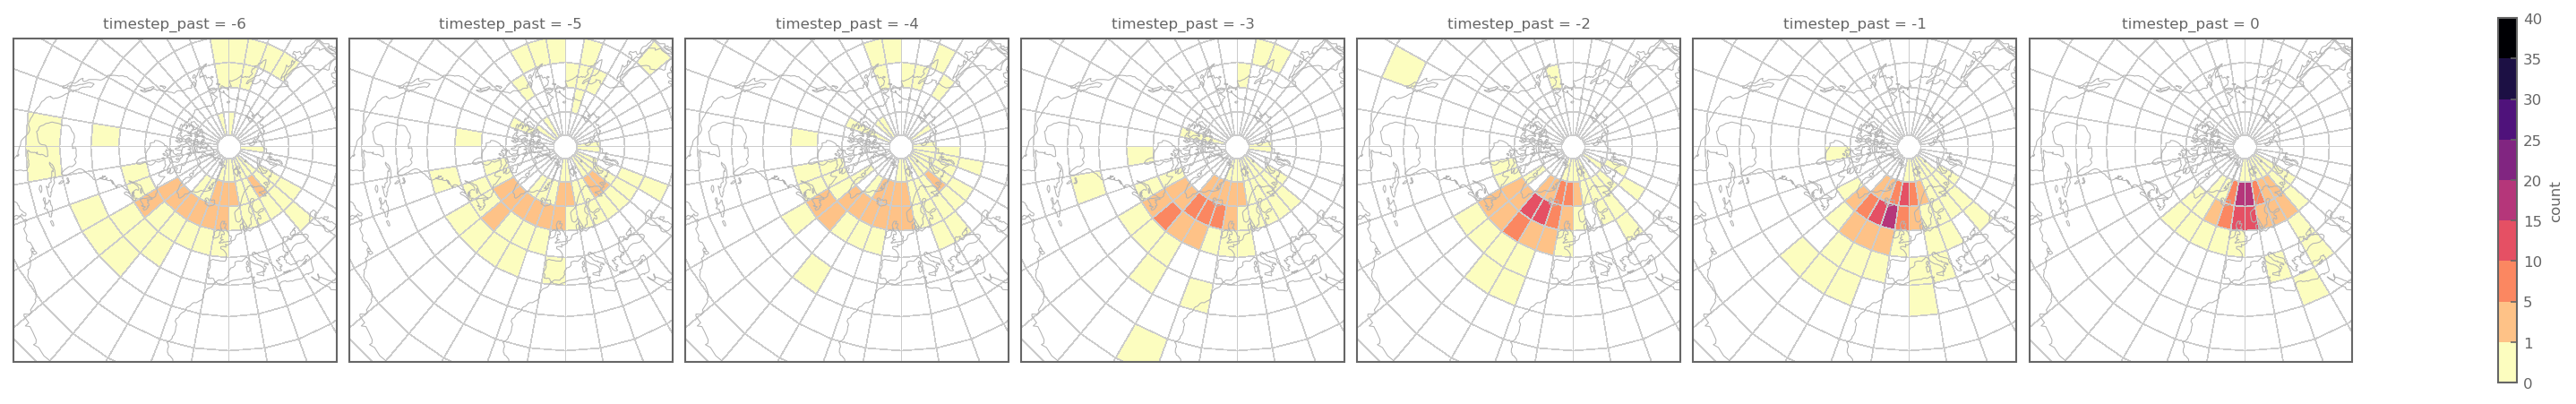

In [39]:
pos_patch_cycs = gdf_cyclones.query("is_cyclone&(patch_category=='large positive')")
df_ = pos_patch_cycs.groupby(["timestep_past","time_of_event", 
                       pd.cut(pos_patch_cycs.cyclone_lon, np.arange(-190,181,10)),
                       pd.cut(pos_patch_cycs.cyclone_lat, np.arange(-45,91,10))]).geometry.count().rename('count').reset_index()
df_['count_one'] = df_['count']>0
df_ = df_.groupby(['timestep_past','cyclone_lon','cyclone_lat'])['count'].sum().reset_index()
df_['cyclone_lon'] = [k.mid for k in df_.cyclone_lon]
df_['cyclone_lat'] = [k.mid for k in df_.cyclone_lat]

ds_ = df_.set_index(['timestep_past','cyclone_lon','cyclone_lat'])['count'].to_xarray()/928*100

plot = ds_.where(ds_>0).plot(col='timestep_past', transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='cyclone_lon', y='cyclone_lat', cmap='magma_r',
         levels=[0,1,5,10,15,20,25,30,35,40], edgecolors='.8', linewidth=.3)

for ax in plot.axs.flatten():
    # ax.coastlines()
    ax.set_extent([-1e7, 5e6, -1e7, 5e6], crs=proj)
    ax.coastlines(color='.7', lw=.5)
    # sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
    # gl = ax.gridlines(
    #     crs=ccrs.PlateCarree(),
    #     draw_labels=False,       # add tick labels
    #     linewidth=0.4,
    #     linestyle="-",
    #     alpha=0.5,
    #     zorder=2,
    #     color='.7'
    # )
    # gl.ylines=False


In [162]:
all_cyclones

,date,track_id,msl,lon,lat,x,y,key,geometry
0,1979-01-01,0.0,100487.303602,-76.048833,45.989150,-4.859531e+06,-1.207219e+06,1979-01-01 0.0,POINT (-4859530.96139 -1207218.83636)
1,1979-01-01,101.0,97338.043428,122.049854,74.149758,1.464296e+06,9.167662e+05,1979-01-01 101.0,POINT (1464295.96158 916766.24675)
2,1979-01-01,67.0,98855.651712,22.982749,46.559554,1.927227e+06,-4.544065e+06,1979-01-01 67.0,POINT (1927226.7302 -4544065.05764)
3,1979-01-01,63.0,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,1979-01-01 63.0,POINT (1089235.31533 -5095836.51674)
4,1979-01-01,22.0,100754.987498,73.433667,48.961326,4.445745e+06,-1.322490e+06,1979-01-01 22.0,POINT (4445744.6143 -1322490.06499)
...,...,...,...,...,...,...,...,...,...
290206,2024-12-30,955856.0,100503.970350,-102.183367,57.591066,-3.522528e+06,7.605272e+05,2024-12-30 955856.0,POINT (-3522528.20672 760527.22572)
290207,2024-12-30,955852.0,101709.656783,6.671551,19.660674,1.011669e+06,-8.648989e+06,2024-12-30 955852.0,POINT (1011669.11336 -8648988.53791)
290208,2024-12-30,955944.0,96591.911384,24.654133,71.221191,8.559414e+05,-1.864881e+06,2024-12-30 955944.0,POINT (855941.38005 -1864881.02438)
290209,2024-12-31,955936.0,97715.058098,170.721027,60.375923,5.288183e+05,3.236749e+06,2024-12-31 955936.0,POINT (528818.29025 3236748.6743)


ValueError: Could not interpret value `x` for `x`. An entry with this name does not appear in `data`.

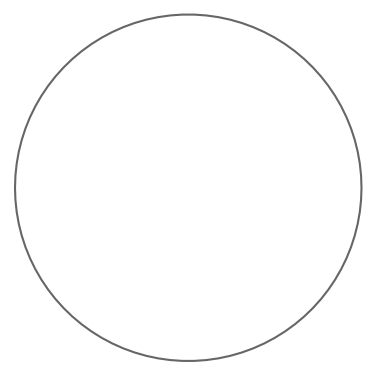

In [82]:
fig, ax = plt.subplots(figsize=(6,3),subplot_kw = dict(projection=proj))
sns.kdeplot(pos_blob_cycs, x='x', y='y', fill=True, transform=proj, cmap='magma_r')
ax.set_extent([-1e7, 5e6, -1e7, 0e6], crs=proj)
ax.coastlines(color='.6', lw=1)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)


/tmp/ipykernel_2999807/4051974330.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ = pos_blob_cycs.groupby([


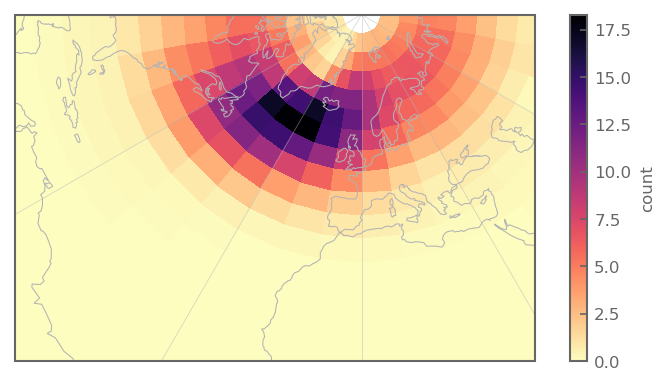

In [80]:
pos_blob_cycs = all_cyclones.query("lat>0").query("msl<99000")
df_ = pos_blob_cycs.groupby([ 
                       pd.cut(pos_blob_cycs.lon, np.arange(-190,181,10)),
                       pd.cut(pos_blob_cycs.lat, np.arange(-45,91,5))]).geometry.count().rename('count').reset_index()
df_['lon'] = [k.mid for k in df_.lon]
df_['lat'] = [k.mid for k in df_.lat]

ds_ = df_.set_index(['lon','lat'])['count'].to_xarray()/46

plot = ds_.rolling(lon=3, lat=3, center=True).mean().ffill('lon').bfill('lon').plot( transform = ccrs.PlateCarree(),
         subplot_kws=dict(projection=proj), x='lon', y='lat', cmap='magma_r',
         edgecolors='none', linewidth=.3, aspect=2, size=3)

# for ax in plot.axes.flatten():
ax = plot.axes
ax.set_extent([-1e7, 5e6, -1e7, 0e6], crs=proj)
ax.coastlines(color='.7', lw=.5)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
    # sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)
gl.ylines=False


In [145]:
df = pd.read_csv('/home/rogui7909/code/predict_rain_norway/bonus/table(5).csv', sep=';', decimal=",").dropna()
df = df.iloc[:,[0,2,3]].dropna()
df.columns = ['station','time','pr']
df['time'] = pd.to_datetime(df.time, format = "%d.%m.%Y",)
df = df.set_index(['time','station'])
df['pr'] = df.pr.astype(float).clip(0)
df['pr'] = df['pr'].where(df['pr']>0).fillna(0)
df = df.unstack().pr.loc['2000':'2024']

In [ ]:
df.dropna().mean()*365.25

Bergen - Florida
(1, 1000]    13.522245
(-1, 1]      11.477070
Name: count, dtype: float64

In [153]:
pd.cut(df.iloc[:,0], [-1,1,1000]).value_counts()/25

Bergen - Florida
(1, 1000]    197.56
(-1, 1]      167.68
Name: count, dtype: float64

IndexError: tuple index out of range

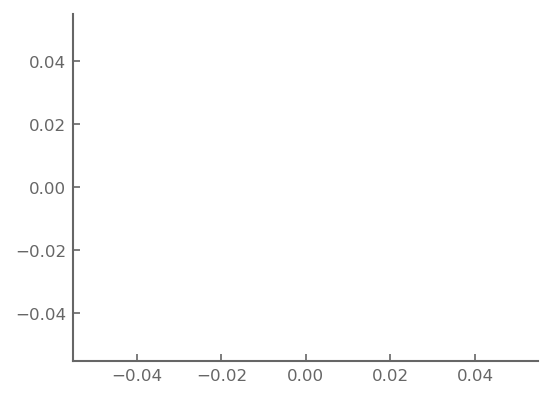

In [110]:
df.pr.plot.hist(bins=[0])